In [51]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [4]:
info = {'cgpa':[8,7,6,5],'resume_score':[8,9,10,12],'lpa':[4,5,6,7]}
df = pd.DataFrame(info,index=None)

In [5]:
df

,cgpa,resume_score,lpa
0,8,8,4
1,7,9,5
2,6,10,6
3,5,12,7


In [18]:
def initialize_parameters(layer_dims):
    np.random.seed(3)
    parameters = {}
    L = len(layer_dims)
    
    for l in range(1,L):
        parameters['W' + str(l)] = np.ones((layer_dims[l-1],layer_dims[l])) * 0.1
        parameters['b' + str(l)] = np.zeros((layer_dims[l],1))

    return parameters

In [40]:
params = initialize_parameters([2,2,1])

In [30]:
def linear_forward(W,b,A_prev):
    return np.dot(W.T,A_prev) + b

In [83]:
def L_layer_forward(X,parameters):
    A = X
    L = len(parameters) // 2

    for l in range(1,L+1):
        A_prev = A
        W1 = parameters['W'+str(l)]
        b1 = parameters['b'+str(l)]
        # print("A"+str(l-1)+": ",A_prev)
        # print("W"+str(l)+": ",W1)
        # print("b"+str(l)+": ",b1)
        # print("__"*20)

        A = linear_forward(W1,b1,A_prev)
        # print("A"+str(l)+": ",A)
        # print("**"*20)

    return A,A_prev

In [43]:
X = df[['cgpa','resume_score']].values[0].reshape(2,1)
y = df[['lpa']].values[0][0]

In [52]:
y_hat,A1 = L_layer_forward(X,params)

A0:  [[8]
 [8]]
W1:  [[0.1 0.1]
 [0.1 0.1]]
b1:  [[0.]
 [0.]]
________________________________________
A1:  [[1.6]
 [1.6]]
****************************************
A1:  [[1.6]
 [1.6]]
W2:  [[0.1]
 [0.1]]
b2:  [[0.]]
________________________________________
A2:  [[0.32]]
****************************************


In [57]:
y_hat = y_hat[0][0]

In [58]:
def update_parameters(params,y,y_hat,A1,X):
    params['W2'][0][0] = params['W2'][0][0] + (.001*2*(y-y_hat)*A1[0][0])
    params['W2'][1][0] = params['W2'][1][0] + (.001*2*(y-y_hat)*A1[1][0])
    params['b2'][0][0] = params['W2'][1][0] + (.001*2*(y-y_hat))

    params['W1'][0][0] = params['W1'][0][0] + (.001*2*(y-y_hat)*params['W2'][0][0]*X[0][0])
    params['W1'][0][1] = params['W1'][0][1] + (.001*2*(y-y_hat)*params['W2'][0][0]*X[1][0])
    params['b1'][0][0] = params['b1'][0][0] + (.001*2*params['W2'][0][0])

    params['W1'][1][0] = params['W1'][1][0] + (.001*2*(y-y_hat)*params['W2'][1][0]*X[0][0])
    params['W1'][1][1] = params['W1'][1][1] + (.001*2*(y-y_hat)*params['W2'][1][0]*X[1][0])
    params['b1'][0][0] = params['b1'][0][0] + (.001*2*params['W2'][1][0])

In [67]:
y_hat

np.float64(0.32000000000000006)

In [84]:
parameters = initialize_parameters([2,2,1])
epochs = 1000
Loss = []
for i in range(epochs):
    
    for j in range(df.shape[0]):
        X = df[['cgpa','resume_score']].values[j].reshape(2,1)
        y = df[['lpa']].values[j][0] 

        y_hat,A1 = L_layer_forward(X,parameters)
        y_hat = y_hat[0][0]

        update_parameters(parameters,y,y_hat,A1,X)
        Loss.append((y-y_hat)**2)

    print("Epoch - ",i+1,np.array(Loss).mean())
parameters


Epoch -  1 25.326037691839012
Epoch -  2 21.837350666717256
Epoch -  3 17.733372708931064
Epoch -  4 14.121154050838392
Epoch -  5 11.565941855943151
Epoch -  6 9.83317999878641
Epoch -  7 8.604181335158325
Epoch -  8 7.686991666027719
Epoch -  9 6.975163720515844
Epoch -  10 6.406201433814962
Epoch -  11 5.940871183317956
Epoch -  12 5.553186900494448
Epoch -  13 5.225209069853346
Epoch -  14 4.944138748642302
Epoch -  15 4.700594442215447
Epoch -  16 4.487541308837985
Epoch -  17 4.299600128024125
Epoch -  18 4.132587158099112
Epoch -  19 3.9831994635198384
Epoch -  20 3.848794691790647
Epoch -  21 3.727233785358015
Epoch -  22 3.616766594410281
Epoch -  23 3.5159473310363354
Epoch -  24 3.4235711602043906
Epoch -  25 3.338626009013597
Epoch -  26 3.2602554969213378
Epoch -  27 3.187730103709456
Epoch -  28 3.120424515748146
Epoch -  29 3.0577996592418746
Epoch -  30 2.9993883268270034
Epoch -  31 2.9447835861183105
Epoch -  32 2.893629361652396
Epoch -  33 2.845612729203744
Epoch - 

{'W1': array([[-1.23930667,  1.30433998],
        [-0.49827937,  2.05438695]]),
 'b1': array([[8.10421246],
        [0.        ]]),
 'W2': array([[0.80196585],
        [0.31918173]]),
 'b2': array([[0.31918534]])}

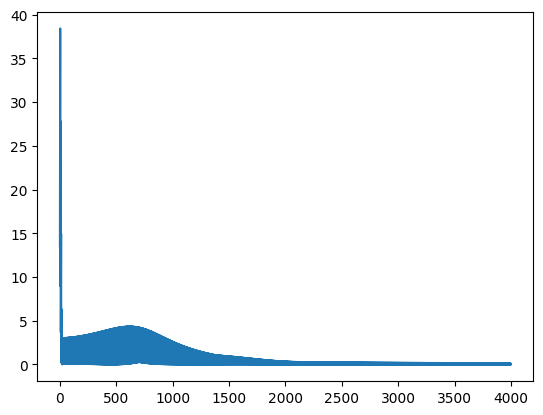

In [81]:
plt.plot(range(4000),Loss)

In [85]:
parameters

{'W1': array([[-1.23930667,  1.30433998],
        [-0.49827937,  2.05438695]]),
 'b1': array([[8.10421246],
        [0.        ]]),
 'W2': array([[0.80196585],
        [0.31918173]]),
 'b2': array([[0.31918534]])}